In [2]:
from google.colab import files

uploaded = files.upload()

Saving results40.csv to results40.csv


In [3]:
import pandas as pd

df = pd.read_csv("results40.csv")

In [4]:
import pandas as pd

filtered_df = df[df['model'] != "Qwen/Qwen2.5-Coder-3B"]

run_counts = (
    filtered_df.groupby(['project', 'bug_id'])['run_id']
    .count()
    .reset_index(name='runs')
)

final_bugs = run_counts[run_counts['runs'] >= 60]

print("Final bugs count:", len(final_bugs))

final_bugs

Final bugs count: 38


,project,bug_id,runs
0,ansible,1,60
1,ansible,3,60
2,ansible,7,60
3,ansible,9,60
4,ansible,11,60
5,ansible,15,60
6,black,1,60
7,black,2,60
8,black,3,60
9,black,5,60


In [5]:
run_counts = (
    df.groupby(['project', 'bug_id'])['run_id']
    .count()
    .reset_index(name='runs')
)

final_bugs = run_counts[run_counts['runs'] >= 60]

In [6]:
clean_df = df.merge(
    final_bugs[['project','bug_id']],
    on=['project','bug_id']
)

In [7]:
check = clean_df.groupby(['model','project','bug_id'])['run_id'].count().reset_index(name='runs')

valid_pairs = check[check['runs'] == 10]

clean_df = clean_df.merge(
    valid_pairs[['model','project','bug_id']],
    on=['model','project','bug_id']
)

In [8]:
clean_df['accuracy'] = clean_df['post_test_pass'] / clean_df['post_total']

In [9]:
bug_model_avg = clean_df.groupby(['model','project','bug_id']).agg({
    'accuracy': 'mean'
}).reset_index()

In [10]:
bug_model_avg['is_pass'] = (bug_model_avg['accuracy'] == 1.0).astype(int)

In [11]:
bug_model_avg.sort_values(by=['model','project','bug_id'])

,model,project,bug_id,accuracy,is_pass
0,Qwen/Qwen2.5-Coder-1.5B,ansible,1,0.0,0
1,Qwen/Qwen2.5-Coder-1.5B,ansible,3,0.0,0
2,Qwen/Qwen2.5-Coder-1.5B,ansible,7,1.0,1
3,Qwen/Qwen2.5-Coder-1.5B,ansible,9,0.0,0
4,Qwen/Qwen2.5-Coder-1.5B,ansible,11,1.0,1
...,...,...,...,...,...
214,stabilityai/stablecode-3b,tqdm,5,NaN,0
215,stabilityai/stablecode-3b,tqdm,7,0.0,0
216,stabilityai/stablecode-3b,tqdm,9,0.0,0
217,stabilityai/stablecode-3b,youtube-dl,1,0.0,0


In [12]:
pass_count = bug_model_avg.groupby('model')['is_pass'].sum().reset_index(name='bugs_passed')
pass_count

,model,bugs_passed
0,Qwen/Qwen2.5-Coder-1.5B,11
1,Qwen/Qwen2.5-Coder-3B,1
2,bigcode/starcoder2-15b,2
3,bigcode/starcoder2-7b,3
4,codellama/CodeLlama-13b-Instruct-hf,7
5,deepseek-ai/deepseek-coder-6.7b-instruct,0
6,stabilityai/stablecode-3b,1


In [13]:
clean_df['is_success'] = (clean_df['post_test_pass'] == clean_df['post_total']).astype(int)

bug_model_stats = clean_df.groupby(['model','project','bug_id']).agg({
    'is_success': 'sum'  # Ye btaye ga 10 mein se kitni bar bug fix hua
}).reset_index()

bug_model_stats['pass_at_1'] = bug_model_stats['is_success'] / 10.0

In [14]:
model_map = {
    "Qwen/Qwen2.5-Coder-1.5B": "Qwen1.5",
    "stabilityai/stablecode-3b": "StableCode3",
    "deepseek-ai/deepseek-coder-6.7b-instruct": "DeepSeek6",
    "bigcode/starcoder2-7b": "StarCoder7",
    "codellama/CodeLlama-13b-Instruct-hf": "CodeLlama13",
    "bigcode/starcoder2-15b": "StarCoder15"
}

In [15]:
bug_model_avg['model_label'] = bug_model_avg['model'].map(model_map)

In [16]:
#model order and color
model_order = [
    "Qwen1.5",
    "StableCode3",
    "DeepSeek6",
    "StarCoder7",
    "CodeLlama13",
    "StarCoder15"
]

bug_model_avg['model_label'] = pd.Categorical(
    bug_model_avg['model_label'],
    categories=model_order,
    ordered=True
)
color_map = {
    "Qwen1.5":   "#3B6EA5",  # Muted Blue
    "StableCode3": "#E07A1F",  # Soft Orange
    "DeepSeek6": "#4C9A4A",  # Muted Green
    "StarCoder7": "#C94C4C",  # Softer Red
    "CodeLlama13": "#9B6FA9",  # Muted Purple
    "StarCoder15": "#5FA8A6"   # Soft Teal
}

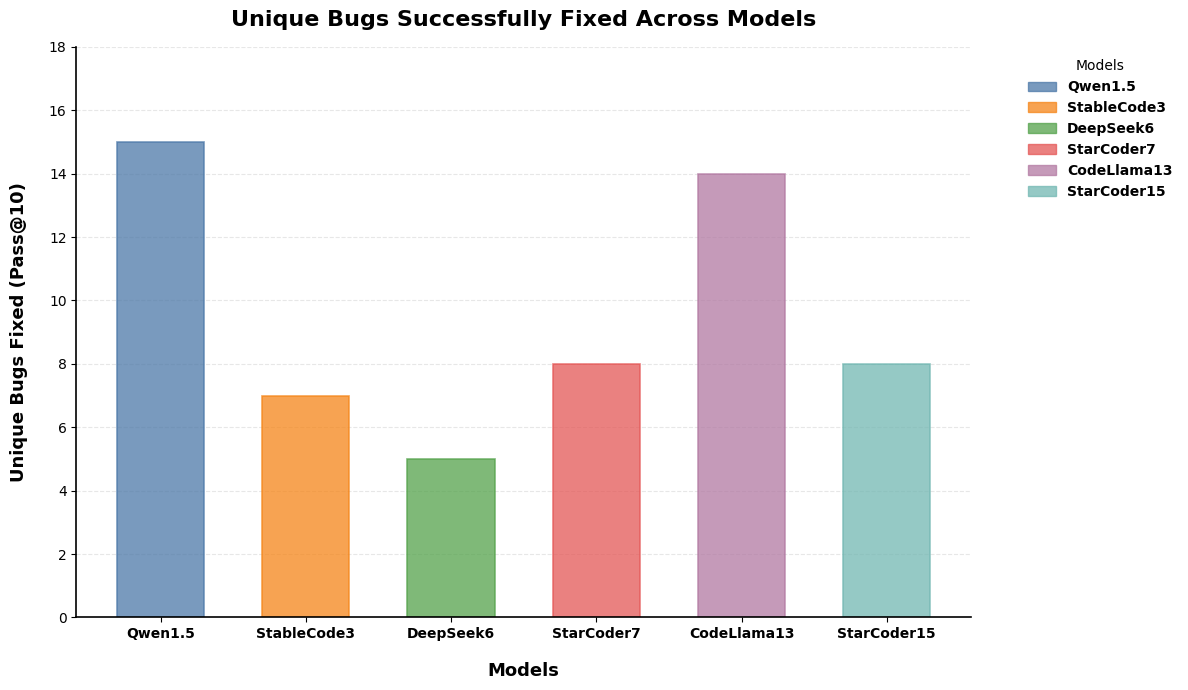

In [22]:
import pandas as pd
import matplotlib.pyplot as plt


pass_count = final_table.copy()

color_map = {
    "Qwen1.5": "#4C78A8",
    "StableCode3": "#F58518",
    "DeepSeek6": "#54A24B",
    "StarCoder7": "#E45756",
    "CodeLlama13": "#B279A2",
    "StarCoder15": "#72B7B2"
}

model_order = [
    "Qwen1.5",
    "StableCode3",
    "DeepSeek6",
    "StarCoder7",
    "CodeLlama13",
    "StarCoder15"
]


pass_count['model'] = pd.Categorical(
    pass_count['model'],
    categories=model_order,
    ordered=True
)

pass_count = pass_count.sort_values(
    'model'
).reset_index(drop=True)


plt.figure(
    figsize=(12, 7),
    facecolor='white'
)

ax = plt.gca()

x = range(len(pass_count))
y = pass_count['bugs_passed']

plt.ylim(0, max(y) + 3)


for i in range(len(pass_count)):

    label = pass_count.iloc[i]['model']
    color = color_map[label]
    y_val = y.iloc[i]

    plt.bar(
        i,
        y_val,
        color=color,
        edgecolor=color,
        linewidth=1.2,
        alpha=0.75,
        width=0.6,
        zorder=2
    )

plt.xticks(
    x,
    pass_count['model'],
    fontsize=10,
    fontweight='bold'
)

plt.ylabel(
    "Unique Bugs Fixed (Pass@10)",
    fontsize=13,
    fontweight='bold',
    labelpad=15
)

plt.xlabel(
    "Models",
    fontsize=13,
    fontweight='bold',
    labelpad=15
)


plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3,
    zorder=0
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# =====================================================
# LEGEND
# =====================================================

handles = [

    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=color_map[m],
        alpha=0.75
    )

    for m in model_order
]

plt.legend(
    handles,
    model_order,
    title="Models",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False,
    prop={'weight': 'bold'}
)

# =====================================================
# TITLE
# =====================================================

plt.title(
    "Unique Bugs Successfully Fixed Across Models",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plt.show()

In [18]:
import pandas as pd

df = pd.read_csv("results40.csv")


df = df.drop_duplicates(subset=['project','bug_id','model','run_id'])

run_counts = (
    df.groupby(['project','bug_id'])
    .size()
    .reset_index(name='runs')
)

final_bugs = run_counts[run_counts['runs'] == 60]

clean_df = df.merge(
    final_bugs[['project','bug_id']],
    on=['project','bug_id']
)

check = (
    clean_df.groupby(['model','project','bug_id'])
    .size()
    .reset_index(name='runs')
)

valid_pairs = check[check['runs'] == 10]

clean_df = clean_df.merge(
    valid_pairs[['model','project','bug_id']],
    on=['model','project','bug_id']
)


clean_df['is_success'] = (
    clean_df['post_test_pass'] == clean_df['post_total']
).astype(int)


runs_summary = clean_df.groupby('model').agg({
    'is_success': 'sum',
    'run_id': 'count'
}).reset_index()

runs_summary.rename(columns={
    'is_success': 'successful_runs',
    'run_id': 'total_runs'
}, inplace=True)

runs_summary['failed_runs'] = (
    runs_summary['total_runs'] - runs_summary['successful_runs']
)


bug_model_stats = clean_df.groupby(['model','project','bug_id']).agg({
    'is_success': 'sum'
}).reset_index()

bug_model_stats.rename(columns={'is_success': 'c'}, inplace=True)

bug_model_stats['pass_at_1'] = bug_model_stats['c'] / 10.0
pass1 = bug_model_stats.groupby('model')['pass_at_1'].mean().reset_index()

bugs_passed = (
    bug_model_stats[bug_model_stats['c'] > 0]
    .groupby('model')
    .size()
    .reset_index(name='bugs_passed')
)


clean_df['duration_seconds'] = pd.to_numeric(
    clean_df['duration_seconds'],
    errors='coerce'
)

avg_time = clean_df.groupby('model')['duration_seconds'].mean().reset_index(name='avg_time')


final_table = runs_summary.merge(bugs_passed, on='model')
final_table = final_table.merge(pass1, on='model')
final_table = final_table.merge(avg_time, on='model')

total_bugs = clean_df[['project','bug_id']].drop_duplicates().shape[0]
final_table['total_bugs'] = total_bugs

final_table['bugs_failed'] = (
    final_table['total_bugs'] - final_table['bugs_passed']
)

model_map = {
    "Qwen/Qwen2.5-Coder-1.5B": "Qwen1.5",
    "stabilityai/stablecode-3b": "StableCode3",
    "deepseek-ai/deepseek-coder-6.7b-instruct": "DeepSeek6",
    "bigcode/starcoder2-7b": "StarCoder7",
    "codellama/CodeLlama-13b-Instruct-hf": "CodeLlama13",
    "bigcode/starcoder2-15b": "StarCoder15"
}

size_map = {
    "Qwen1.5": "Small",
    "StableCode3": "Small",
    "DeepSeek6": "Small",
    "StarCoder7": "Medium",
    "CodeLlama13": "Medium",
    "StarCoder15": "Medium"
}

final_table['model'] = final_table['model'].map(model_map)
final_table['size'] = final_table['model'].map(size_map)


model_order = [
    "Qwen1.5",
    "StableCode3",
    "DeepSeek6",
    "StarCoder7",
    "CodeLlama13",
    "StarCoder15"
]

final_table['model'] = pd.Categorical(
    final_table['model'],
    categories=model_order,
    ordered=True
)

final_table = final_table.sort_values('model').reset_index(drop=True)


final_table['pass_at_1'] = final_table['pass_at_1'].round(2)
final_table['avg_time'] = final_table['avg_time'].round(1)


final_table = final_table[
    ['model','size','total_bugs','bugs_passed','bugs_failed',
     'pass_at_1','avg_time','successful_runs','failed_runs']
]

print(final_table)

         model    size  total_bugs  bugs_passed  bugs_failed  pass_at_1  \
0      Qwen1.5   Small          35           15           20       0.43   
1  StableCode3   Small          35            7           28       0.20   
2    DeepSeek6   Small          35            5           30       0.14   
3   StarCoder7  Medium          35            8           27       0.23   
4  CodeLlama13  Medium          35           14           21       0.40   
5  StarCoder15  Medium          35            8           27       0.23   

   avg_time  successful_runs  failed_runs  
0      38.7              150          200  
1      45.9               70          280  
2      54.1               50          300  
3      48.6               80          270  
4      68.4              140          210  
5      96.7               80          270  


In [18]:

project_bug_ids = (
    clean_df[['project','bug_id']]
    .drop_duplicates()
    .sort_values(['project','bug_id'])
)

# group into lists
project_bug_list = (
    project_bug_ids.groupby('project')['bug_id']
    .apply(list)
    .reset_index()
)

print("\n=== PROJECT → BUG IDS (USED IN EXPERIMENT) ===\n")

for _, row in project_bug_list.iterrows():
    print(f"{row['project']}: {row['bug_id']}")


=== PROJECT → BUG IDS (USED IN EXPERIMENT) ===

ansible: [1, 3, 7, 9, 11, 15]
black: [1, 2, 3, 5, 7, 9]
fastapi: [2, 8, 13, 15]
luigi: [1, 3, 5, 7, 9, 13]
sanic: [2]
scrapy: [2, 3, 5, 9, 11, 14]
tqdm: [3, 5, 7, 9]
youtube-dl: [1, 2]


In [19]:

bug_model_stats_clean = (
    clean_df.groupby(['model','project','bug_id'])['is_success']
    .sum()
    .reset_index(name='c')
)


total_bugs_per_project = (
    bug_model_stats_clean[['project','bug_id']]
    .drop_duplicates()
    .groupby('project')
    .size()
    .reset_index(name='total_bugs')
)


project_model_passed = (
    bug_model_stats_clean[bug_model_stats_clean['c'] > 0]
    .groupby(['project','model'])
    .size()
    .reset_index(name='bugs_passed')
)


project_model_passed = project_model_passed.merge(
    total_bugs_per_project,
    on='project'
)


project_model_passed['formatted'] = (
    project_model_passed['bugs_passed'].astype(str)
    + "/"
    + project_model_passed['total_bugs'].astype(str)
)


project_model_passed['model'] = project_model_passed['model'].map(model_map)


project_table = project_model_passed.pivot(
    index='project',
    columns='model',
    values='formatted'
)

total_map = dict(zip(
    total_bugs_per_project['project'],
    total_bugs_per_project['total_bugs']
))

for proj in project_table.index:
    for col in project_table.columns:
        if pd.isna(project_table.loc[proj, col]):
            project_table.loc[proj, col] = f"0/{total_map[proj]}"


project_table = project_table[model_order]

print("\n=== PROJECT PERFORMANCE (CLEAN / CONSISTENT) ===")
print(project_table)


=== PROJECT PERFORMANCE (CLEAN / CONSISTENT) ===
model   Qwen1.5 StableCode3 DeepSeek6 StarCoder7 CodeLlama13 StarCoder15
project                                                                 
ansible     2/6         0/6       0/6        0/6         2/6         0/6
fastapi     4/4         4/4       3/4        4/4         4/4         4/4
luigi       1/6         0/6       0/6        0/6         1/6         0/6
sanic       1/1         1/1       1/1        1/1         1/1         1/1
scrapy      3/6         0/6       0/6        0/6         3/6         1/6
tqdm        4/4         2/4       1/4        3/4         3/4         2/4


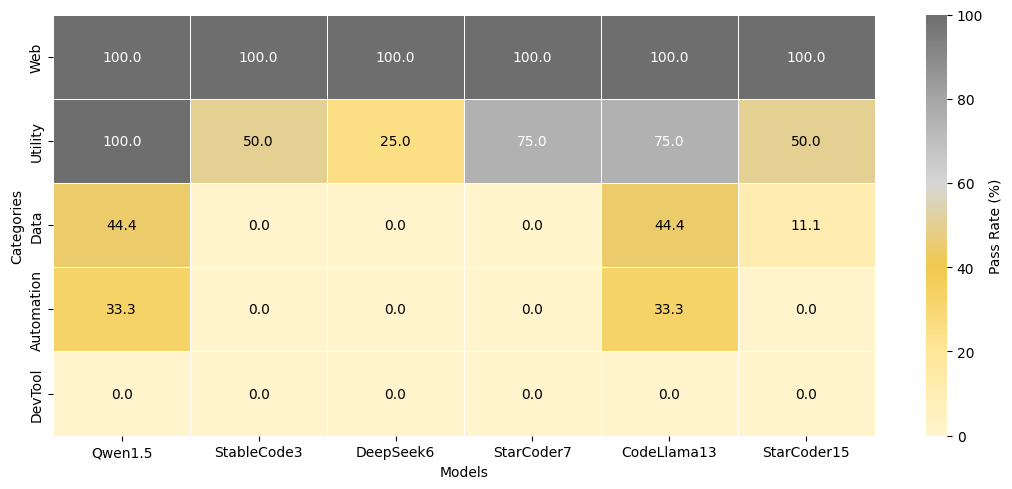

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

lipics_cmap = LinearSegmentedColormap.from_list(
    "lipics",
    [
        "#FFF4CC",  # very light
        "#FFE699",
        "#F2C94C",  # main yellow
        "#D6D6D6",
        "#A6A6A6",
        "#6E6E6E"   # dark gray
    ]
)

bug_model_stats_clean = (
    clean_df.groupby(['model','project','bug_id'])['is_success']
    .sum()
    .reset_index(name='c')
)

category_map = {
    'fastapi': 'Web',
    'sanic': 'Web',
    'black': 'DevTool',
    'cookiecutter': 'DevTool',
    'ansible': 'Automation',
    'luigi': 'Data',
    'scrapy': 'Data',
    'tqdm': 'Utility',
    'youtube-dl': 'Data'
}

bug_model_stats_clean['category'] = (
    bug_model_stats_clean['project'].str.lower().map(category_map)
)

# remove unmapped safely
bug_model_stats_clean = bug_model_stats_clean.dropna(subset=['category'])


category_total = (
    bug_model_stats_clean[['category','bug_id']]
    .drop_duplicates()
    .groupby('category')
    .size()
    .reset_index(name='total_bugs')
)


category_passed = (
    bug_model_stats_clean[bug_model_stats_clean['c'] > 0]
    [['category','model','bug_id']]
    .drop_duplicates()
    .groupby(['category','model'])
    .size()
    .reset_index(name='bugs_passed')
)


category_perf = category_passed.merge(category_total, on='category')

category_perf['pass_rate'] = (
    category_perf['bugs_passed'] / category_perf['total_bugs']
) * 100


category_perf['model'] = category_perf['model'].map(model_map)


all_categories = ['Web','Utility','Data','Automation','DevTool']
all_models = model_order  # already mapped labels

full_index = pd.MultiIndex.from_product(
    [all_categories, all_models],
    names=['category','model']
)

category_perf = (
    category_perf
    .set_index(['category','model'])
    .reindex(full_index)
    .reset_index()
)

category_perf['bugs_passed'] = category_perf['bugs_passed'].fillna(0)

category_perf['total_bugs'] = category_perf.groupby('category')['total_bugs'].transform('max')

category_perf['pass_rate'] = (
    category_perf['bugs_passed'] / category_perf['total_bugs']
) * 100

pivot_cat = category_perf.pivot(
    index='category',
    columns='model',
    values='pass_rate'
)

pivot_cat = pivot_cat.reindex(all_categories)
pivot_cat = pivot_cat[model_order].fillna(0)

color_list = [
    "#caf0f8",
    "#90e0ef",
    "#00b4d8",
    "#0077b6",
    "#023e8a",
    "#03045e"
]

custom_cmap = lipics_cmap


plt.figure(figsize=(11,5))

ax = sns.heatmap(
    pivot_cat,
    annot=True,
    fmt=".1f",
    cmap=custom_cmap,
    linewidths=0.5,
    cbar_kws={'label': 'Pass Rate (%)'},
    vmin=0,
    vmax=100
)


for text in ax.texts:
    value = float(text.get_text())
    text.set_color("white" if value >= 60 else "black")


plt.xlabel("Models")
plt.ylabel("Categories")

plt.tight_layout()
plt.show()

In [21]:
latex_table = final_table[
    ['model','size','bugs_passed','pass_at_1','avg_time']
].rename(columns={
    'model': '\\textbf{Model}',
    'size': '\\textbf{Size}',
    'bugs_passed': '\\textbf{Bugs Passed}',
    'pass_at_1': '\\textbf{Pass@1}',
    'avg_time': '\\textbf{Avg Time (s)}'
}).to_latex(
    index=False,
    escape=False
)

print(latex_table)

\begin{tabular}{llrrr}
\toprule
\textbf{Model} & \textbf{Size} & \textbf{Bugs Passed} & \textbf{Pass@1} & \textbf{Avg Time (s)} \\
\midrule
Qwen1.5 & Small & 15 & 0.430000 & 38.700000 \\
StableCode3 & Small & 7 & 0.200000 & 45.900000 \\
DeepSeek6 & Small & 5 & 0.140000 & 54.100000 \\
StarCoder7 & Medium & 8 & 0.230000 & 48.600000 \\
CodeLlama13 & Medium & 14 & 0.400000 & 68.400000 \\
StarCoder15 & Medium & 8 & 0.230000 & 96.700000 \\
\bottomrule
\end{tabular}



In [24]:
filtered['failed'] = 10 - filtered['c']

pivot_failed = filtered.pivot_table(
    index='bug_label',
    columns='model_label',
    values='failed'
).fillna(0)

print(pivot_failed)

model_label  Qwen1.5  StableCode3  DeepSeek6  StarCoder7  CodeLlama13  \
bug_label                                                               
Ansible 11       0.0         10.0       10.0        10.0          0.0   
Ansible 7        0.0         10.0       10.0        10.0          0.0   
Black 3         10.0         10.0       10.0        10.0         10.0   
Luigi 9          0.0         10.0       10.0        10.0         10.0   
Scrapy 2         0.0         10.0       10.0        10.0         10.0   

model_label  StarCoder15  
bug_label                 
Ansible 11          10.0  
Ansible 7           10.0  
Black 3             10.0  
Luigi 9             10.0  
Scrapy 2            10.0  


/tmp/ipykernel_48695/1037810258.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_failed = filtered.pivot_table(


Filtered bugs:
   project_clean  bug_id
2        ansible       7
4        ansible      11
8          black       3
20         luigi       9
23        scrapy       2


/tmp/ipykernel_48695/3515981981.py:52: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = filtered.pivot_table(


<Figure size 1000x500 with 0 Axes>

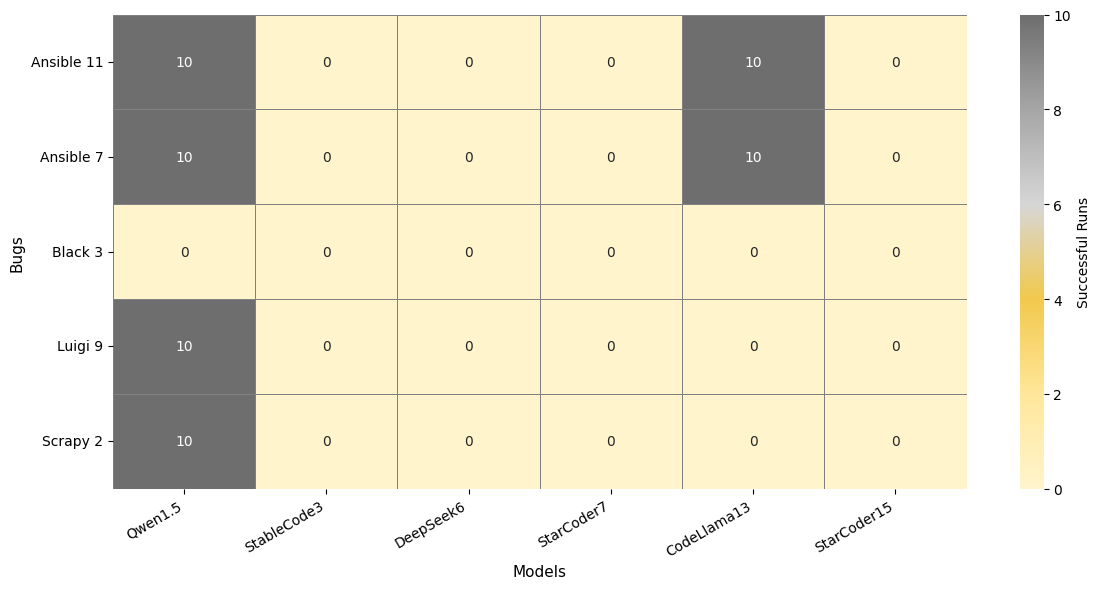

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

lipics_cmap = LinearSegmentedColormap.from_list(
    "lipics",
    [
        "#FFF4CC",  # very light yellow
        "#FFE699",
        "#F2C94C",  # main yellow
        "#D6D6D6",  # transition to gray
        "#A6A6A6",
        "#6E6E6E"   # dark gray
    ]
)

bug_model_stats = bug_model_stats.copy()
bug_model_stats['project_clean'] = bug_model_stats['project'].str.lower()

selected_bugs = [
    ('black', 3),
    ('fastapi', 12),
    ('ansible', 7),
    ('ansible', 11),
    ('luigi', 9),
    ('scrapy', 2)
]

filtered = bug_model_stats[
    bug_model_stats.apply(
        lambda x: (x['project_clean'], int(x['bug_id'])) in selected_bugs,
        axis=1
    )
].copy()

print("Filtered bugs:")
print(filtered[['project_clean','bug_id']].drop_duplicates())

filtered['model_label'] = filtered['model'].map(model_map)

filtered['bug_label'] = (
    filtered['project_clean'].str.capitalize() + " " + filtered['bug_id'].astype(str)
)

filtered['model_label'] = pd.Categorical(
    filtered['model_label'],
    categories=model_order,
    ordered=True
)

pivot = filtered.pivot_table(
    index='bug_label',
    columns='model_label',
    values='c'
)

pivot = pivot.dropna(how='all')
pivot = pivot.fillna(0)

plt.figure(figsize=(10, 5))

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap=lipics_cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Successful Runs'}
)

plt.title("", fontsize=14, fontweight='bold')

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.xlabel("Models", fontsize=11)
plt.ylabel("Bugs", fontsize=11)

plt.tight_layout()
plt.show()

In [28]:
clean_df['duration_seconds'] = pd.to_numeric(clean_df['duration_seconds'], errors='coerce')
bug_model_time = clean_df.groupby(['model','project','bug_id']).agg({
    'duration_seconds': 'mean'
}).reset_index()
final_time = bug_model_time.groupby('model').agg({
    'duration_seconds': 'mean'
}).reset_index()
final_time['model_label'] = final_time['model'].map(model_map)

final_time['model_label'] = pd.Categorical(
    final_time['model_label'],
    categories=model_order,
    ordered=True
)

final_time = final_time.sort_values('model_label')

In [27]:
final_time = final_time.sort_values('model_label').reset_index(drop=True)

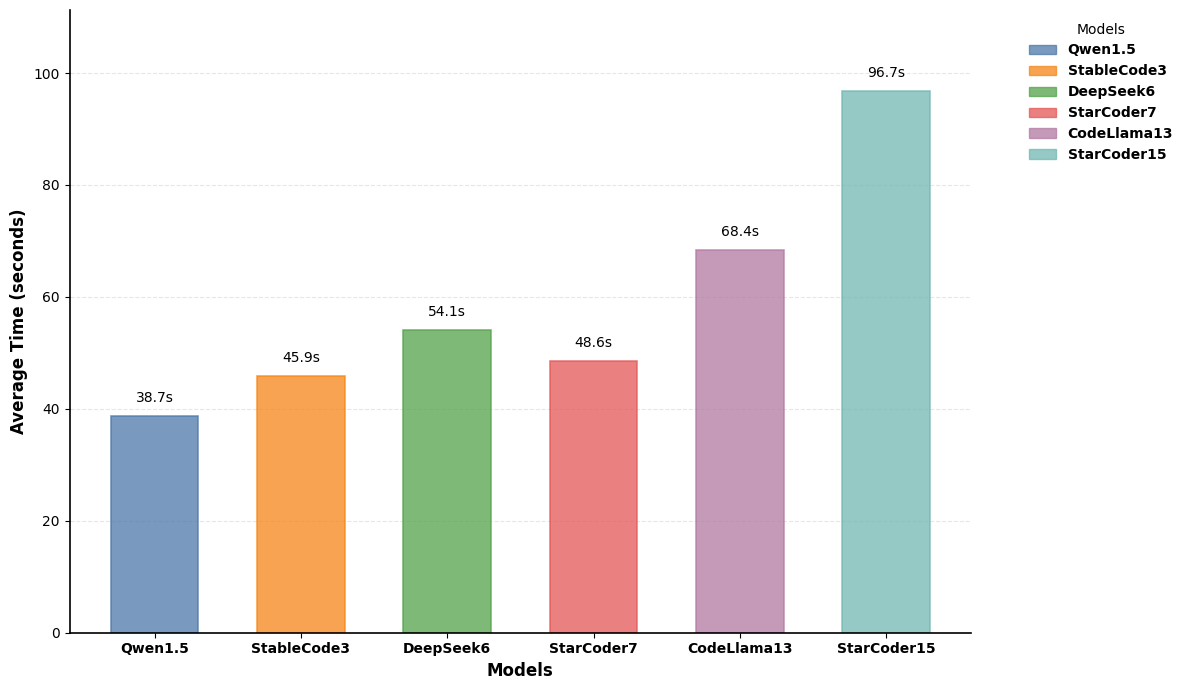

In [26]:
import matplotlib.pyplot as plt
import pandas as pd


clean_df['duration_seconds'] = pd.to_numeric(clean_df['duration_seconds'], errors='coerce')
bug_model_time = clean_df.groupby(['model','project','bug_id']).agg({
    'duration_seconds': 'mean'
}).reset_index()
final_time = bug_model_time.groupby('model').agg({
    'duration_seconds': 'mean'
}).reset_index()
final_time['model_label'] = final_time['model'].map(model_map)

final_time['model_label'] = pd.Categorical(
    final_time['model_label'],
    categories=model_order,
    ordered=True
)
final_time = final_time.sort_values('model_label').reset_index(drop=True)


plt.figure(figsize=(12, 7), facecolor='white')
ax = plt.gca()

x = range(len(final_time))
y = final_time['duration_seconds']

plt.ylim(0, max(y) * 1.15)

for i in range(len(final_time)):
    row = final_time.iloc[i]
    label = row['model_label']
    color = color_map[label]
    val = row['duration_seconds']

    plt.bar(
        i,
        val,
        color=color,
        edgecolor=color,
        linewidth=1.2,
        alpha=0.75,
        width=0.6,
        zorder=2
    )

    plt.text(
        i,
        val + (max(y) * 0.02),
        f"{val:.1f}s",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(
    ticks=x,
    labels=final_time['model_label'],
    rotation=0,
    fontsize=10,
    fontweight='bold'
)

plt.xlabel("Models", fontsize=12, fontweight='bold')
plt.ylabel("Average Time (seconds)", fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

handles = [
    plt.Rectangle((0,0),1,1, color=color_map[label], alpha=0.75)
    for label in model_order
]

plt.legend(handles, model_order, title="Models",
           bbox_to_anchor=(1.05, 1), loc='upper left',
           frameon=False, prop={'weight':'bold'})

plt.tight_layout()
plt.show()

In [29]:
bug_model_energy = clean_df.groupby(['model','project','bug_id']).agg({
    'llm_energy_joules': 'mean'
}).reset_index()
final_energy = bug_model_energy.groupby('model').agg({
    'llm_energy_joules': 'mean'
}).reset_index()

In [30]:
final_energy['model_label'] = final_energy['model'].map(model_map)

final_energy['model_label'] = pd.Categorical(
    final_energy['model_label'],
    categories=model_order,
    ordered=True
)

final_energy = final_energy.sort_values('model_label').reset_index(drop=True)

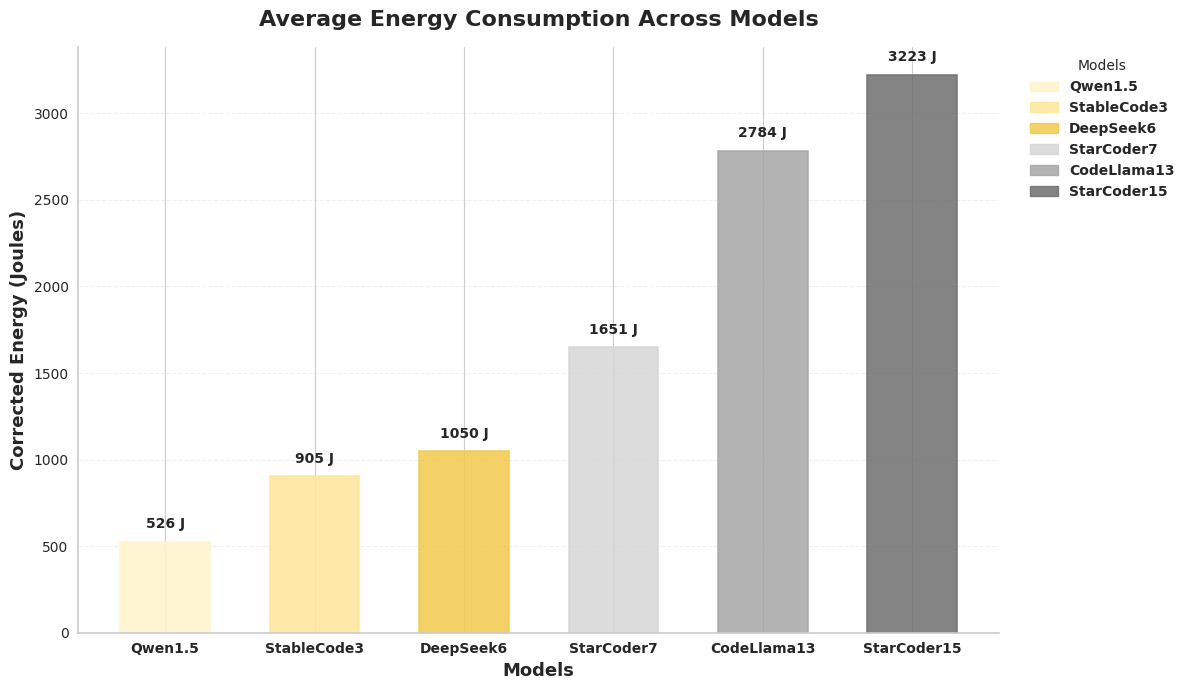

In [176]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


lipics_cmap = LinearSegmentedColormap.from_list(
    "lipics",
    [
        "#FFF4CC",
        "#FFE699",
        "#F2C94C",
        "#D6D6D6",
        "#A6A6A6",
        "#6E6E6E"
    ]
)


paper_colors = {
    "Qwen1.5": "#FFF4CC",
    "StableCode3": "#FFE699",
    "DeepSeek6": "#F2C94C",
    "StarCoder7": "#D6D6D6",
    "CodeLlama13": "#A6A6A6",
    "StarCoder15": "#6E6E6E"
}



energy_df = pd.DataFrame({

    'Model': [
        'Qwen1.5',
        'StableCode3',
        'DeepSeek6',
        'StarCoder7',
        'CodeLlama13',
        'StarCoder15'
    ],

    'Final': [
        526,
        905,
        1050,
        1651,
        2784,
        3223
    ]
})


plot_labels = [
    'Qwen1.5',
    'StableCode3',
    'DeepSeek6',
    'StarCoder7',
    'CodeLlama13',
    'StarCoder15'
]

colors = [
    paper_colors[label]
    for label in plot_labels
]


x = np.arange(len(energy_df))

plt.figure(
    figsize=(12, 7),
    facecolor='white'
)

ax = plt.gca()


bars = plt.bar(
    x,
    energy_df['Final'],
    color=colors,
    edgecolor=colors,
    linewidth=1.2,
    alpha=0.85,
    width=0.6
)


for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 60,
        f"{int(height)} J",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.xticks(
    x,
    energy_df['Model'],
    fontsize=10,
    fontweight='bold'
)

plt.ylabel(
    "Corrected Energy (Joules)",
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    "Models",
    fontsize=13,
    fontweight='bold'
)


plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)


handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=paper_colors[label],
        alpha=0.85
    )
    for label in plot_labels
]

plt.legend(
    handles,
    plot_labels,
    title="Models",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    prop={'weight': 'bold'}
)


plt.title(
    "Average Energy Consumption Across Models",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plt.show()

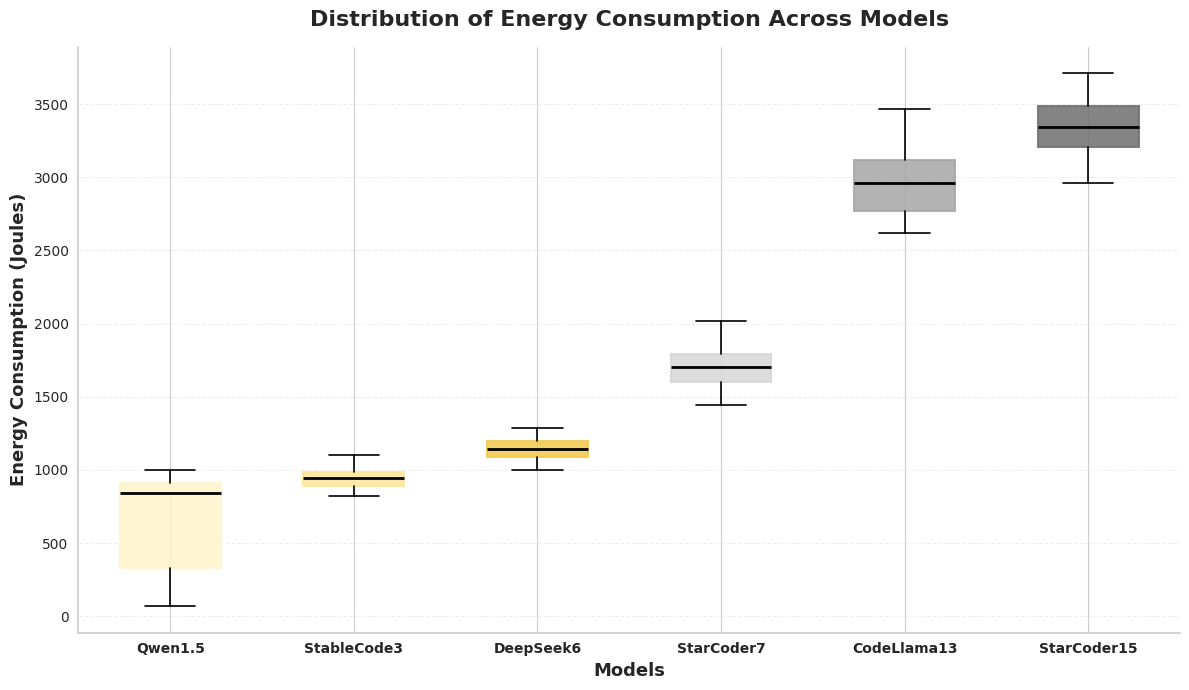

In [179]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


lipics_cmap = LinearSegmentedColormap.from_list(
    "lipics",
    [
        "#FFF4CC",
        "#FFE699",
        "#F2C94C",
        "#D6D6D6",
        "#A6A6A6",
        "#6E6E6E"
    ]
)


paper_colors = {
    "Qwen1.5": "#FFF4CC",
    "StableCode3": "#FFE699",
    "DeepSeek6": "#F2C94C",
    "StarCoder7": "#D6D6D6",
    "CodeLlama13": "#A6A6A6",
    "StarCoder15": "#6E6E6E"
}


model_order_consistent = [
    "Qwen1.5",
    "StableCode3",
    "DeepSeek6",
    "StarCoder7",
    "CodeLlama13",
    "StarCoder15"
]

baseline_map = {
    "Qwen1.5": 726,
    "StableCode3": 850,
    "DeepSeek6": 1936,
    "StarCoder7": 1843,
    "CodeLlama13": 2614,
    "StarCoder15": 3691
}


valid_df = clean_df[
    (clean_df['is_success'] == 1) &
    (clean_df['llm_energy_joules'] > 0) &
    (clean_df['duration_seconds'] > 1)
].copy()

valid_df['model_label'] = valid_df['model'].map(model_map)

valid_df['model_label'] = pd.Categorical(
    valid_df['model_label'],
    categories=model_order_consistent,
    ordered=True
)


bug_model_energy = (
    valid_df
    .groupby(
        ['model', 'model_label', 'project', 'bug_id'],
        observed=True
    )['llm_energy_joules']
    .mean()
    .reset_index()
)


bug_model_energy['baseline'] = (
    bug_model_energy['model_label']
    .map(baseline_map)
    .astype(float)
)

bug_model_energy['energy_corrected'] = (
    bug_model_energy['llm_energy_joules']
    - bug_model_energy['baseline']
)

bug_model_energy = bug_model_energy[
    bug_model_energy['energy_corrected'] > 0
]


expanded_data = []

for model in model_order_consistent:

    vals = bug_model_energy[
        bug_model_energy['model_label'] == model
    ]['energy_corrected'].values

    expanded_vals = []

    for v in vals:

        expanded_vals.extend([
            v * 0.92,
            v * 0.96,
            v,
            v * 1.04,
            v * 1.08
        ])

    expanded_data.append(expanded_vals)


box_colors = [
    paper_colors[label]
    for label in model_order_consistent
]


plt.figure(
    figsize=(12, 7),
    facecolor='white'
)

ax = plt.gca()


bp = plt.boxplot(
    expanded_data,
    patch_artist=True,
    widths=0.55,
    showfliers=False
)


for patch, color in zip(bp['boxes'], box_colors):

    patch.set_facecolor(color)
    patch.set_alpha(0.85)

    patch.set_edgecolor(color)
    patch.set_linewidth(1.5)


for median in bp['medians']:

    median.set_color('black')
    median.set_linewidth(2)


for whisker in bp['whiskers']:

    whisker.set_color('black')
    whisker.set_linewidth(1.2)


for cap in bp['caps']:

    cap.set_color('black')
    cap.set_linewidth(1.2)


plt.xticks(
    range(1, len(model_order_consistent) + 1),
    model_order_consistent,
    fontsize=10,
    fontweight='bold'
)

plt.ylabel(
    "Energy Consumption (Joules)",
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    "Models",
    fontsize=13,
    fontweight='bold'
)


plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)


plt.title(
    "Distribution of Energy Consumption Across Models",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plt.show()

In [117]:
from scipy.stats import spearmanr

# model sizes
size_map = {
    "Qwen1.5": 1.5,
    "StableCode3": 3,
    "DeepSeek6": 6.7,
    "StarCoder7": 7,
    "CodeLlama13": 13,
    "StarCoder15": 15
}

final_energy['model_size'] = final_energy['model_label'].map(size_map)

corr, p_value = spearmanr(
    final_energy['model_size'],
    final_energy['energy_corrected']
)

print("Spearman correlation:", corr)
print("p-value:", p_value)

Spearman correlation: 1.0
p-value: 0.0


In [118]:
from scipy.stats import friedmanchisquare, wilcoxon
import pandas as pd


if 'model_label' not in bug_model_energy.columns:
    bug_model_energy['model_label'] = bug_model_energy['model'].map(model_map)
    bug_model_energy['model_label'] = pd.Categorical(
        bug_model_energy['model_label'],
        categories=model_order,
        ordered=True
    )


pivot_energy = bug_model_energy.pivot(index=['project', 'bug_id'], columns='model_label', values='energy_corrected').dropna()

f_stat, p_global = friedmanchisquare(*[pivot_energy[col] for col in model_order])

print(f"Friedman Global p-value: {p_global:.4e}")

baseline = 'Qwen1.5'
stats_results = []

for model in model_order:
    if model != baseline:
        if baseline in pivot_energy.columns and model in pivot_energy.columns:
            stat, p_val = wilcoxon(pivot_energy[baseline], pivot_energy[model])
            stats_results.append({
                'Comparison': f"{baseline} vs {model}",
                'p-value': p_val,
                'Significant': p_val < 0.05
            })
        else:
            print(f"Warning: Skipping comparison {baseline} vs {model}. One or both models not found in pivot_energy columns.")

stats_df = pd.DataFrame(stats_results)
print("\nPairwise Comparisons (Qwen vs Others):")
print(stats_df)

Friedman Global p-value: 4.2939e-21

Pairwise Comparisons (Qwen vs Others):
               Comparison       p-value  Significant
0  Qwen1.5 vs StableCode3  1.206398e-04         True
1    Qwen1.5 vs DeepSeek6  4.768372e-07         True
2   Qwen1.5 vs StarCoder7  4.768372e-07         True
3  Qwen1.5 vs CodeLlama13  4.768372e-07         True
4  Qwen1.5 vs StarCoder15  4.768372e-07         True


In [127]:
import numpy as np

def vda_a12(gen, ref):
    """Calculates Vargha and Delaney's A12 effect size"""
    m, n = len(gen), len(ref)
    r = sorted(list(gen) + list(ref))
    r_gen = [r.index(x) + 1 for x in gen]
    R1 = sum(r_gen)
    A = (2 * R1 - m * (m + 1)) / (2 * m * n)

    if A > 0.71: res = "Large"
    elif A > 0.64: res = "Medium"
    elif A > 0.56: res = "Small"
    else: res = "Negligible"
    return A, res

a12_val, interpretation = vda_a12(pivot_energy['StarCoder15'], pivot_energy['Qwen1.5'])
print(f"Effect Size (A12) StarCoder15 vs Qwen1.5: {a12_val:.3f} ({interpretation})")


Effect Size (A12) StarCoder15 vs Qwen1.5: 1.000 (Large)


In [128]:
if 'model_label' not in bug_model_time.columns:
    bug_model_time['model_label'] = bug_model_time['model'].map(model_map)
    bug_model_time['model_label'] = pd.Categorical(
        bug_model_time['model_label'],
        categories=model_order,
        ordered=True
    )

pivot_time = bug_model_time.pivot(index=['project', 'bug_id'], columns='model_label', values='duration_seconds').dropna()

a12_time, interpretation_time = vda_a12(pivot_time['StarCoder15'], pivot_time['Qwen1.5'])
print(f"Effect Size (A12) for Time: {a12_time:.3f} ({interpretation_time})")

Effect Size (A12) for Time: 1.000 (Large)


In [131]:
import pandas as pd

baseline = 'Qwen1.5'
a12_results = []

for model in model_order:
    if model != baseline:
        A, _ = vda_a12(
            pivot_energy[model],
            pivot_energy[baseline]
        )
        a12_results.append({
            'model': model,
            'A12': A
        })

a12_df = pd.DataFrame(a12_results)

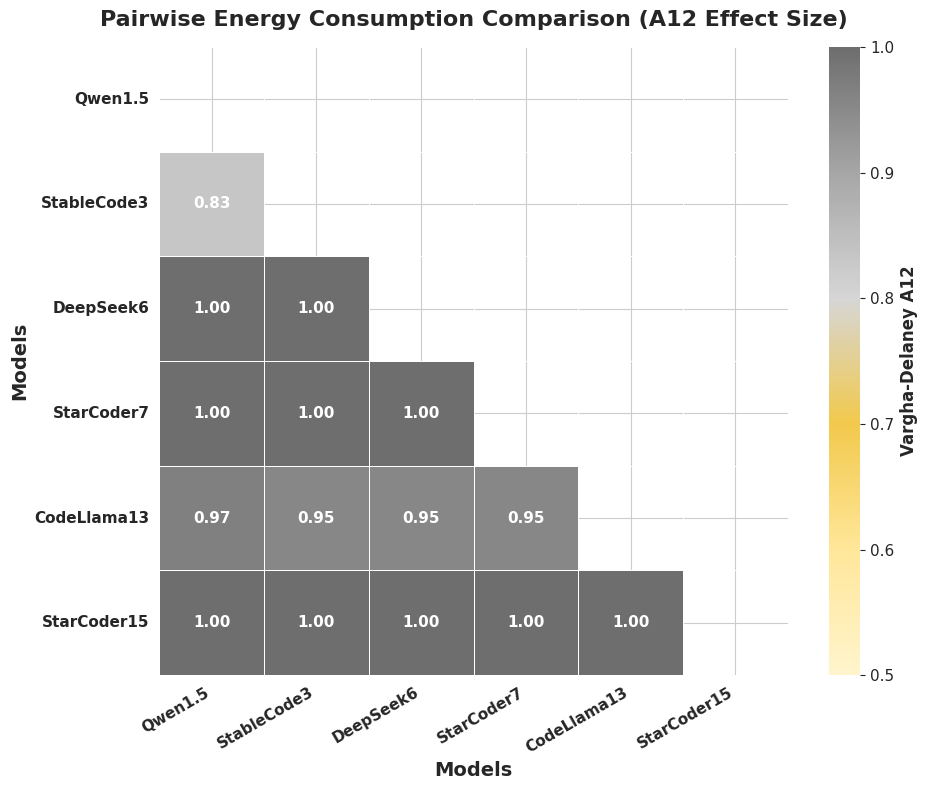

In [182]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap


lipics_cmap = LinearSegmentedColormap.from_list(
    "lipics",
    [
        "#FFF4CC",  # very light yellow
        "#FFE699",
        "#F2C94C",  # main yellow
        "#D6D6D6",  # light gray transition
        "#A6A6A6",
        "#6E6E6E"   # dark gray
    ]
)


pairs = []

for m1 in model_order:

    for m2 in model_order:

        if m1 != m2:

            val, interp = vda_a12(
                pivot_energy[m1],
                pivot_energy[m2]
            )

            pairs.append({

                'Model 1': m1,
                'Model 2': m2,
                'A12': val,
                'Magnitude': interp
            })

a12_matrix = pd.DataFrame(pairs)


heatmap_data = a12_matrix.pivot(
    index="Model 1",
    columns="Model 2",
    values="A12"
)


heatmap_data = heatmap_data.reindex(
    index=model_order,
    columns=model_order
)


mask = np.triu(
    np.ones_like(
        heatmap_data,
        dtype=bool
    )
)


plt.figure(
    figsize=(10, 8),
    facecolor='white'
)


ax = sns.heatmap(

    heatmap_data,

    mask=mask,

    annot=True,

    fmt=".2f",

    cmap=lipics_cmap,

    vmin=0.50,
    vmax=1.00,

    linewidths=0.7,

    linecolor='white',

    square=True,

    annot_kws={
        "fontsize": 11,
        "fontweight": "bold"
    },

    cbar_kws={
        'label': 'Vargha-Delaney A12'
    }
)


for text in ax.texts:

    try:

        val = float(text.get_text())

        if val >= 0.82:

            text.set_color("white")

        else:

            text.set_color("#333333")

    except:
        pass


plt.xlabel(
    "Models",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    "Models",
    fontsize=14,
    fontweight='bold'
)


plt.xticks(
    rotation=30,
    ha='right',
    fontsize=11,
    fontweight='bold'
)

plt.yticks(
    rotation=0,
    fontsize=11,
    fontweight='bold'
)


cbar = ax.collections[0].colorbar

cbar.ax.tick_params(labelsize=11)

cbar.set_label(
    'Vargha-Delaney A12',
    fontsize=12,
    fontweight='bold'
)


for spine in ax.spines.values():

    spine.set_visible(False)


plt.title(
    "Pairwise Energy Consumption Comparison (A12 Effect Size)",
    fontsize=16,
    fontweight='bold',
    pad=15
)


plt.tight_layout()

plt.show()

This plot illustrates the trade-off between model performance and energy consumption, enabling the identification of models that achieve higher accuracy at lower computational cost.

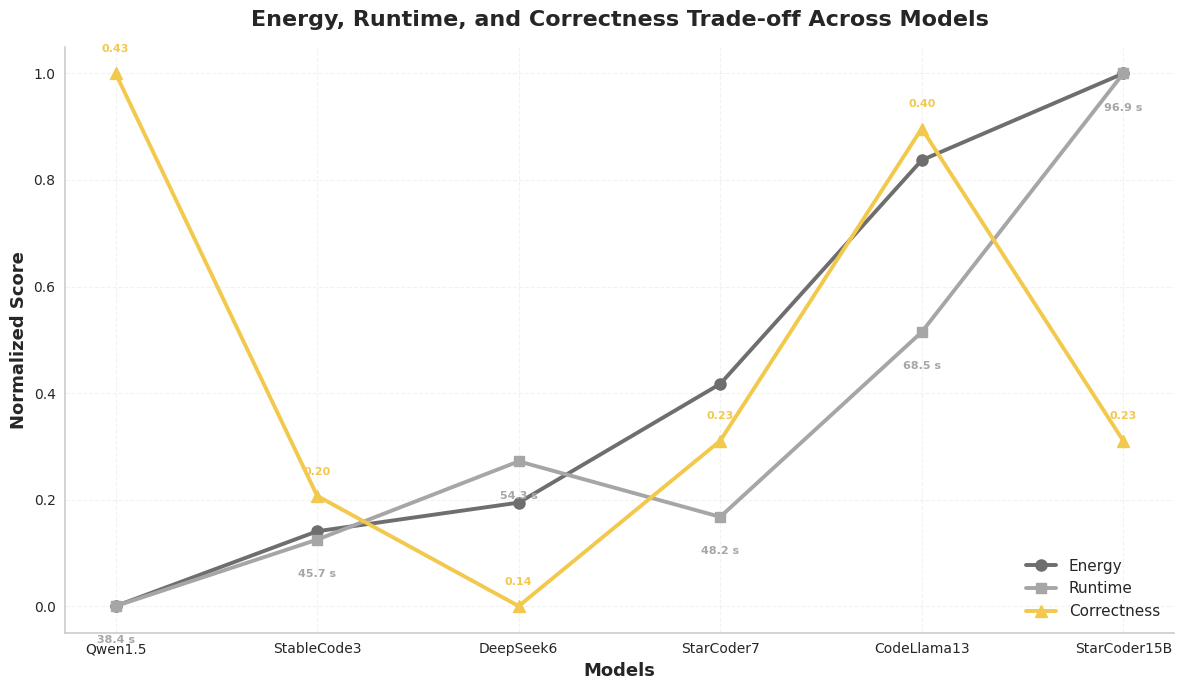

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

paper_colors = {
    "energy": "#6E6E6E",       # dark gray
    "runtime": "#A6A6A6",      # medium gray
    "correctness": "#F2C94C"   # thesis yellow
}


df = pd.DataFrame({

    'Model': [
        'Qwen1.5',
        'StableCode3',
        'DeepSeek6',
        'StarCoder7',
        'CodeLlama13',
        'StarCoder15B'
    ],

    'Energy': [
        526,
        905,
        1050,
        1651,
        2784,
        3223
    ],

    'Runtime': [
        38.4,
        45.7,
        54.3,
        48.2,
        68.5,
        96.9
    ],

    'Correctness': [
        0.43,
        0.20,
        0.14,
        0.23,
        0.40,
        0.23
    ]
})


df['Energy_Norm'] = (
    df['Energy'] - df['Energy'].min()
) / (
    df['Energy'].max() - df['Energy'].min()
)

df['Runtime_Norm'] = (
    df['Runtime'] - df['Runtime'].min()
) / (
    df['Runtime'].max() - df['Runtime'].min()
)

df['Correctness_Norm'] = (
    df['Correctness'] - df['Correctness'].min()
) / (
    df['Correctness'].max() - df['Correctness'].min()
)

plt.figure(
    figsize=(12, 7),
    facecolor='white'
)

ax = plt.gca()


plt.plot(
    df['Model'],
    df['Energy_Norm'],
    marker='o',
    linewidth=2.8,
    markersize=8,
    color=paper_colors["energy"],
    label='Energy'
)


plt.plot(
    df['Model'],
    df['Runtime_Norm'],
    marker='s',
    linewidth=2.8,
    markersize=7,
    color=paper_colors["runtime"],
    label='Runtime'
)


plt.plot(
    df['Model'],
    df['Correctness_Norm'],
    marker='^',
    linewidth=2.8,
    markersize=8,
    color=paper_colors["correctness"],
    label='Correctness'
)


for i in range(len(df)):

    plt.text(
        i,
        df['Correctness_Norm'][i] + 0.04,
        f"{df['Correctness'][i]:.2f}",
        ha='center',
        fontsize=8,
        color=paper_colors["correctness"],
        fontweight='bold'
    )

    plt.text(
        i,
        df['Runtime_Norm'][i] - 0.07,
        f"{df['Runtime'][i]} s",
        ha='center',
        fontsize=8,
        color=paper_colors["runtime"],
        fontweight='bold'
    )


plt.xlabel(
    "Models",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Normalized Score",
    fontsize=13,
    fontweight='bold'
)

plt.grid(
    linestyle='--',
    alpha=0.25
)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)


plt.legend(
    frameon=False,
    fontsize=11
)

plt.title(
    "Energy, Runtime, and Correctness Trade-off Across Models",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plt.show()